In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_maintenance_records

Path to dataset files: C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1


In [2]:
# Set the default figure size
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(color_codes = True)
pd.set_option('display.width', 1200)
pd.set_option('display.max_columns', None)

In [3]:
maintenance_df = load_maintenance_records()

In [4]:
maintenance_df['maintenance_date']=pd.to_datetime(maintenance_df['maintenance_date'])
maintenance_df['year']=pd.to_datetime(maintenance_df['maintenance_date']).dt.year
maintenance_df['month_year']=pd.to_datetime(maintenance_df['maintenance_date']).dt.to_period('M')

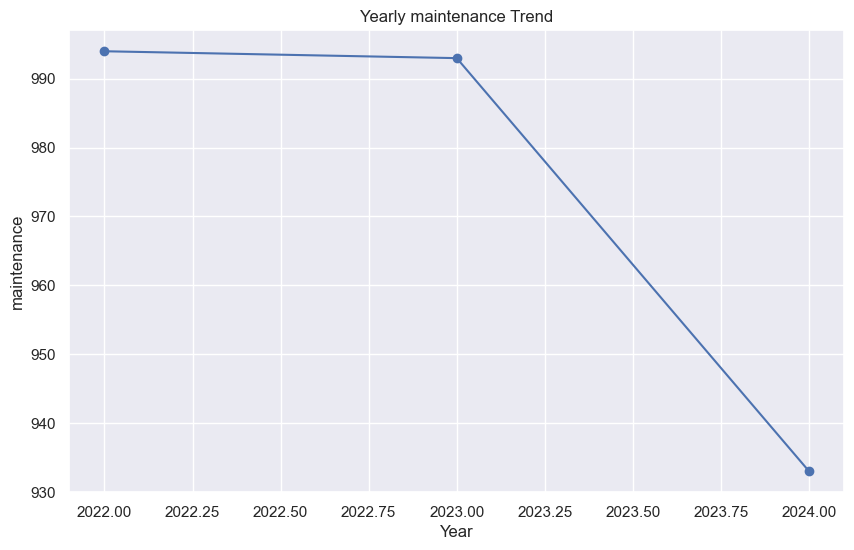

In [5]:
yearly_maintenance_records = (
    maintenance_df.groupby('year')['maintenance_id']
    .count()
    .reset_index()
)

plt.plot(yearly_maintenance_records['year'], yearly_maintenance_records['maintenance_id'], marker='o')
plt.title('Yearly maintenance Trend')
plt.xlabel('Year')
plt.ylabel('maintenance')
plt.grid(True)
plt.show()

In [6]:
print(maintenance_df.head())
print(maintenance_df['service_description'].unique())

  maintenance_id  truck_id maintenance_date maintenance_type  odometer_reading  labor_hours  labor_cost  parts_cost  total_cost facility_location  downtime_hours   service_description  year month_year
0  MAINT00000001  TRK00085       2022-01-01       Inspection            400255          7.8      781.42       10.41      791.83       Kansas City            22.2  Emergency Inspection  2022    2022-01
1  MAINT00000002  TRK00041       2022-01-01             Tire            268041          0.9       80.91     3207.16     3288.07           Seattle             8.0        Scheduled Tire  2022    2022-01
2  MAINT00000003  TRK00090       2022-01-01       Preventive            698915          7.2      733.18     1570.57     2303.75             Miami            16.5    Routine Preventive  2022    2022-01
3  MAINT00000004  TRK00056       2022-01-02       Inspection            416522          2.8      298.80       67.48      366.28       Kansas City            34.6  Emergency Inspection  2022    202

<Axes: xlabel='year', ylabel='count'>

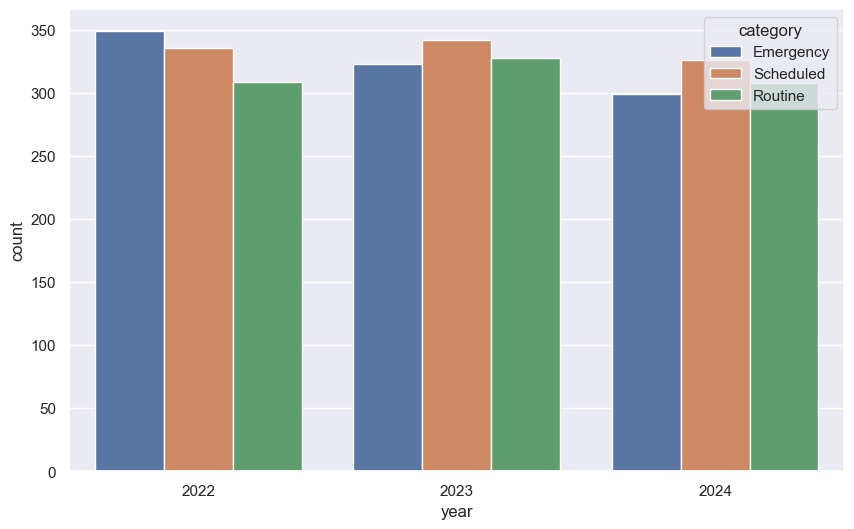

In [7]:
# Create a mapping function
def categorize_service(desc):
    if 'Emergency' in desc:
        return 'Emergency'
    elif 'Scheduled' in desc:
        return 'Scheduled'    
    else:
        return 'Routine'

# Apply to dataframe
maintenance_df['category'] = maintenance_df['service_description'].apply(categorize_service)

# Plot the trend
sns.countplot(data=maintenance_df, x='year', hue='category')

<div style="font-size:20px"> Scheduled Tyres: Dropped from 60 in 2022 to 38 in 2024 (a 36.7% decrease). </div>

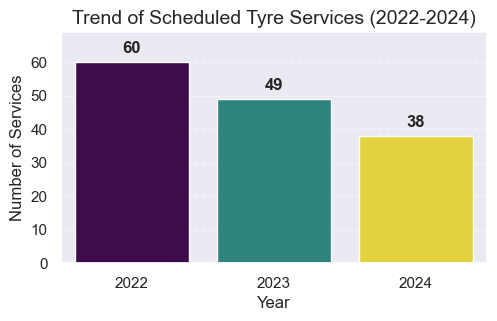

In [11]:
# 1. Filter the data first
# Note: Ensure the column name is exactly 'service_description'
scheduled_tire_df = maintenance_df[maintenance_df['service_description'] == 'Scheduled Tire']

# 2. Create the countplot
plt.figure(figsize=(5.5, 3))

# Assign x to hue and set legend=False to avoid future warnings
ax = sns.countplot(
    data=scheduled_tire_df, 
    x='year', 
    hue='year', 
    palette='viridis', 
    legend=False
)

# 3. Add the number labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10),              # Move the label 10 points above the bar
                textcoords = 'offset points',
                fontsize=12,
                fontweight='bold')

# 4. Optional: Add a bit of headroom to the Y-axis so labels aren't cut off
plt.ylim(0, scheduled_tire_df['year'].value_counts().max() * 1.15)

plt.title('Trend of Scheduled Tyre Services (2022-2024)', fontsize=14)
plt.ylabel('Number of Services', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()